## 강원도 신재생에너지과 기상 상관 관계 분서
이 프로젝트는 강원도 내 신재생에너지 발전 설비 현황, 발전 성과,
지형 기후 포함하여 수집한 데이터를 상관 분석하기 위한 파일입니다.

### 분석 흐름
1 기존에 전처리 후 가공한 기상 D.F을 분석하고자 parquet 파일로 활용
2 수집한 에너지 분야별 데이터와 대응, 상관 관계를 분석
3 이를 통해 시각화 데이터 생성

In [6]:
#수정 가공하기 위해 새로 작성한 코드
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#기상데이터, 에너지 데이터 불러오기
rain = pd.read_parquet("./weather_rain.parquet")
temp = pd.read_parquet("./weather_temp.parquet")
wind = pd.read_parquet("./weather_wind.parquet")
sun = pd.read_parquet("./weather_sun.parquet")

#DF 값의 구역 컬럼명은 관측소로 인식. parquet 원본은 건들지 않는다. 
rain = rain.rename(columns={"구역": "station"})


In [7]:
#관측지점과 행정구역 대응되도록 명시적 테이블화

admin_weather_map = pd.DataFrame({
    "admin_region": [
        "강릉시", "강릉시",  # 추가
        "고성군", "동해시", "삼척시", "속초시",
        "양양군", "영월군", "원주시", "인제군",
        "정선군", "철원군", "춘천시", "춘천시",  # 추가
        "태백시", "평창군", "홍천군", "횡성군"
    ],
    "station": [
        "강릉", "북강릉",   # 추가
        "속초", "동해", "동해", "속초",
        "속초", "영월", "원주", "인제",
        "정선군", "철원", "북춘천", "춘천",  # 추가
        "태백", "대관령", "홍천", "원주"
    ]
})

#행정구역 - 관측소 매핑 적용 코드
# 기상 컬럼 '구역' 행에 맞춰서 admin_region(행정구역)컬럼 정보를 붙인다.(병합)
rain = rain.merge(
    admin_weather_map,
    on="station",
    how="left"
)

#행정구역 단위로 다시 묶어 정리하기. 그러지 않으면 동일 기상값이 여러번 계산된다.
rain_admin = (
    rain
    .groupby(["admin_region", "연도", "월"], as_index=False)
    .mean(numeric_only=True)
)

#매핑 누락있는지 확인하는 코드
rain[rain["admin_region"].isna()]["station"].unique()

array([], dtype=object)

In [ ]:
#강원도 에너지 통계가 지정한 대로 열리는 지 확인
energy_2020 = pd.read_excel(
    "../data/processed/신재생에너지_보급통계_발전량(강원도)_(2021-2023).xlsx",
    sheet_name="2021"
)

energy_2020

,연도,광역지자체,기초지자체,지역별 공급비중,신재생에너지 합계,재생에너지 합계,신에너지 합계,태양열,태양광,풍력,수력,해양,지열,수열,바이오,재생폐기물,연료전지,IGCC
0,2021,강원,강릉시,32.31,"503,632","503,617",15,533,"28,289","17,337",688,-,"2,395",69,"405,396","48,909",15,-
1,2021,강원,고성군,2.12,"32,999","32,999",-,58,"30,318",-,186,-,828,83,"1,523",2,-,-
2,2021,강원,동해시,10.32,"160,919","132,856","28,062",237,"5,862",-,"6,450",-,203,-,"48,185","71,919","28,062",-
3,2021,강원,삼척시,5.66,"88,265","88,265",1,110,"23,714","7,087","2,865",-,482,183,"29,716","24,108",1,-
4,2021,강원,속초시,0.32,"4,974","4,974",-,144,"2,411",1,-,-,439,-,"1,839",139,-,-
5,2021,강원,양구군,1.63,"25,463","25,463",-,130,"22,427",9,52,-,516,-,"2,329",-,-,-
6,2021,강원,양양군,0.67,"10,403","10,403",-,31,"5,606",874,"1,212",-,190,69,"1,576",846,-,-
7,2021,강원,영월군,5.88,"91,580","88,346","3,234",56,"26,369",224,-,-,648,-,"2,807","58,242","3,234",-
8,2021,강원,원주시,3.26,"50,886","50,834",52,236,"33,994",-,-,-,"4,088",-,"8,251","4,265",52,-
9,2021,강원,인제군,2.20,"34,228","34,228",-,178,"26,208",637,465,-,902,7,"5,292",539,-,-


In [ ]:
#시트별로 구분된 데이터를 하나로 통합 
energy_2021 = pd.read_excel(
    "../data/processed/신재생에너지_보급통계_발전량(강원도)_(2021-2023).xlsx",
    sheet_name="2021"
)
energy_2022 = pd.read_excel(
    "../data/processed/신재생에너지_보급통계_발전량(강원도)_(2021-2023).xlsx",
    sheet_name="2022"
)
energy_2023 = pd.read_excel(
    "../data/processed/신재생에너지_보급통계_발전량(강원도)_(2021-2023).xlsx",
    sheet_name="2023"
)

energy_2021["연도"] = 2021
energy_2022["연도"] = 2022
energy_2023["연도"] = 2023

energy = pd.concat([energy_2021, energy_2022, energy_2023], ignore_index=True)

In [13]:
#컬럼 정리

energy = energy.rename(columns={"기초지자체": "admin_region"})

#에너지 데이터 결측 구조 파악
energy.isna().mean().sort_values(ascending=False)
#결측치 NaN은 없으나 이는 일부 에너지원은 설비부재로 인해 발전량이 0으로 기록된 것으로 확인 됨.

연도              0.0
광역지자체           0.0
admin_region    0.0
지역별 공급비중        0.0
신재생에너지 합계       0.0
재생에너지 합계        0.0
신에너지 합계         0.0
태양열             0.0
태양광             0.0
풍력              0.0
수력              0.0
해양              0.0
지열              0.0
수열              0.0
바이오             0.0
재생폐기물           0.0
연료전지            0.0
IGCC            0.0
dtype: float64

In [ ]:
#기상데이터가 월별 평균 기준, 에너지 발전량이 연도 기준이기 때문에 기상데이터를 연도 단위로 변환
# 강수량과 수력 발전 상관 관계를 예시로 작성.

#연도 단위 총 강수량 계산.
#수력 발전은 연중 누적 강수량의 영향을 받는 특성을 고려한 계산 활용이다.
rain_year = (
    rain_admin
    .groupby(["admin_region", "연도"], as_index=False)
    .agg({"강수량_mm": "sum"}) #수력 발전은 sum 사용
)

#수력 발전량 데이터 추출
energy_hydro = energy[["admin_region", "연도", "수력"]]

#기상과 수력에너지 병합(연도) 이때 원본 훼손되지 않게 새로은 df 생성
hydro_df = energy_hydro.merge(
    rain_year,
    on=["admin_region", "연도"],
    how="left"
)

import numpy as np

hydro_df["수력"] = (
    hydro_df["수력"]
    .astype(str)
    .str.replace(",", "")     # 천 단위 콤마 제거
    .replace("-", np.nan)     # '-' → NaN 으로 변환
    .astype(float)
)
#NaN으로 처리한 건 미집계 또는 설비 부재를 파악하기 위함

hydro_df = hydro_df[hydro_df["수력"] > 0] #수력 발전이 실제 존재하는 경우만 출력되게.

In [ ]:
# 안정성 검증
hydro_df["수력"].isna().sum()
hydro_df["수력"].dtype #dtype('float64')로 출력되어야 검증 완료. 

dtype('float64')

In [ ]:
hydro_df[["수력", "강수량_mm"]].corr(method="spearman") #누락값을 제외한 상관도를 측정하는 상관 계수

,수력,강수량_mm
수력,1.000000,-0.233676
강수량_mm,-0.233676,1.000000


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')   # 윈도우: 맑은 고딕
# plt.rc('font', family='NanumGothic')   # 리눅스/맥: 나눔고딕 설치 시 사용
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

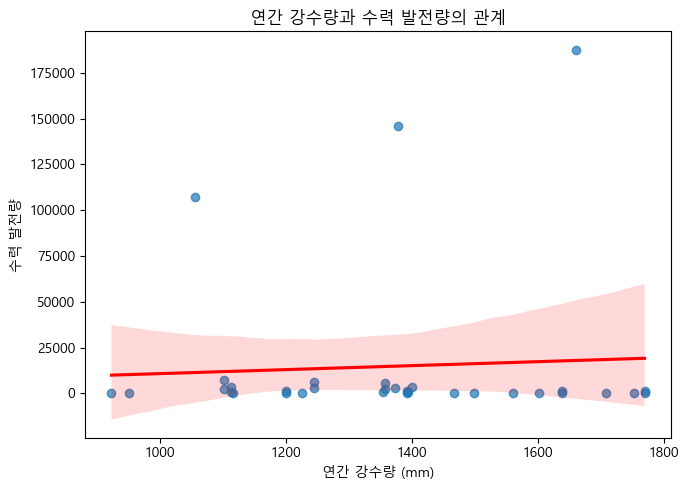

In [23]:
#위와 같이 진행한 분석 토대로 시각화 데이터 형성

plt.figure(figsize=(7, 5))

sns.regplot(
    data=hydro_df,
    x="강수량_mm",
    y="수력",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("연간 강수량과 수력 발전량의 관계")
plt.xlabel("연간 강수량 (mm)")
plt.ylabel("수력 발전량")
plt.tight_layout()
plt.show()


연간 강수량이 많을수록 수력 발전량이 어떻게 변하는지 지역, 연도 단위 관측값으로 시각화했다.
산점도(점)은 특정 행정구역x 특정 연도 한쌍의 관측값. 점이 많을 수록 관측 데이터가 많다.
x = 그 지역 해당 연도 총 강수량 / y = 그 지역 해당 연도 수력 발전량 

빨간 선(추세선)은 전체 데이터에서 평균적인 관계 방향을 요약한 선.
오른쪽 위로 기울어 있으면 양의 관계, 아래로 내려가면 음의 관계고 수평에 가까우면 관계가 적다.
=Spearman 상관계수 부호와 대응
옅은 붉은 색 면적은 이 정도 범위 안에 추세선이 존재할 가능성이 높고 좁을수록 관계가 비교적 안정적이다.

선에서 일부 멀리 떨어진 점
비는 많으나 발전량 낮음 :  설비 부족/ 댐 용량 한계
비는 적으나 발전량 높음 :  대규모 수력 설비 존재
수력 설비 규모 및 지형적 요인의 차이에 기인한 것으로 판단

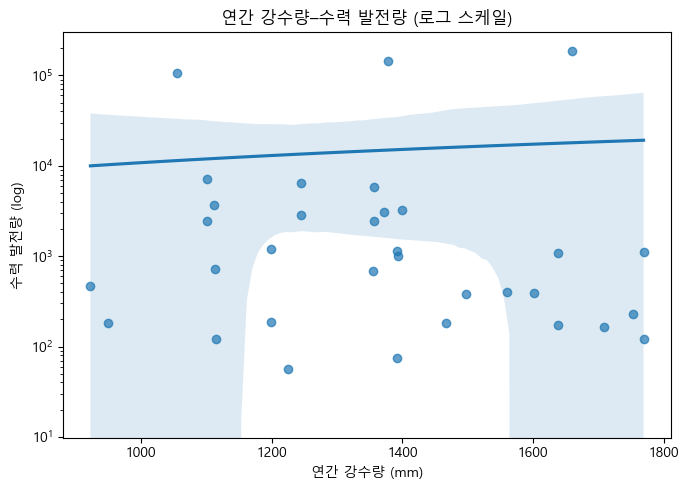

In [31]:
#일부 관측 데이터가 과도하게 커 전체를 누를 때 로그 스케일로 조절.
plt.figure(figsize=(7, 5))

sns.regplot(
    data=hydro_df,
    x="강수량_mm",
    y="수력",
    scatter_kws={"alpha": 0.7}
)

plt.yscale("log")
plt.title("연간 강수량–수력 발전량 (로그 스케일)")
plt.xlabel("연간 강수량 (mm)")
plt.ylabel("수력 발전량 (log)")
plt.tight_layout()
plt.show()

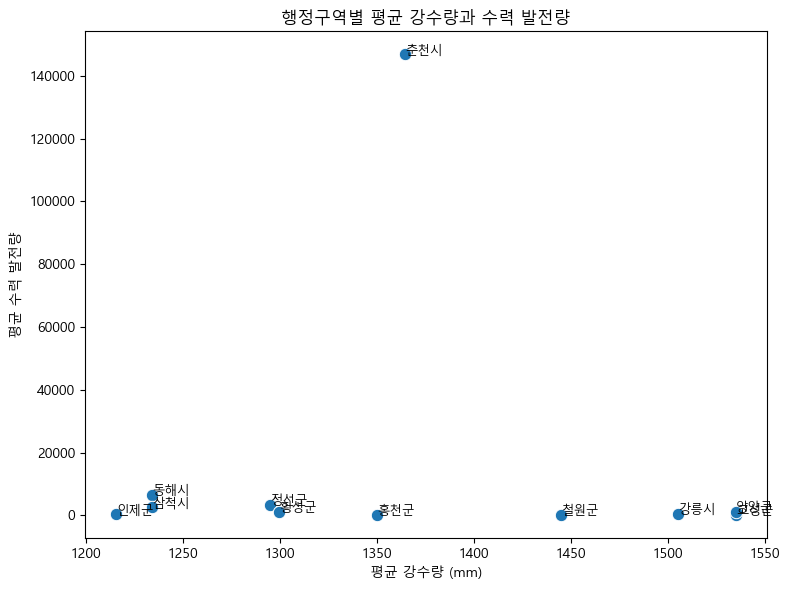

In [32]:
#행정구역 평균 기준
hydro_region = (
    hydro_df
    .groupby("admin_region", as_index=False)
    .agg({
        "강수량_mm": "mean",
        "수력": "mean"
    })
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=hydro_region,
    x="강수량_mm",
    y="수력",
    s=80
)

for _, row in hydro_region.iterrows():
    plt.text(
        row["강수량_mm"],
        row["수력"],
        row["admin_region"],
        fontsize=9
    )

plt.title("행정구역별 평균 강수량과 수력 발전량")
plt.xlabel("평균 강수량 (mm)")
plt.ylabel("평균 수력 발전량")
plt.tight_layout()
plt.show()

